# Numerical mixing

This notebook plots numerical mixing diagnostics for all experiments.

In [2]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
# zstar
crs_zstar = get_geo_coords(catalogue["zstar-PPMH3"]["static"], catalogue["zstar-PPMH3"]["vc"])

∫nm_zstar = vertical_sum(catalogue["zstar-PPMH3"]["monthly"])
∫nm_zstar = dropdims(∫nm_zstar, dims = (3, 4))
zm_var_diss_zstar = zonal_variance_dissipation(catalogue["zstar-PPMH3"]["monthly"])
zm_var_diss_zstar = dropdims(zm_var_diss_zstar, dims = (1, 4))

# hycom
crs_hycom = get_geo_coords(catalogue["hycom-PPMH3"]["static"], catalogue["hycom-PPMH3"]["vc"])

∫nm_hycom = vertical_sum(catalogue["hycom-PPMH3"]["monthly"])
∫nm_hycom = dropdims(∫nm_hycom, dims = (3, 4))
zm_var_diss_hycom = zonal_variance_dissipation(catalogue["hycom-PPMH3"]["monthly"])
zm_var_diss_hycom = dropdims(zm_var_diss_hycom, dims = (1, 4))
nothing

In [3]:
fig = Figure(size = (1000, 1000))

colorrange = (-5e-4, 5e-4)
colormap = :balance
ax_zstar = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Depth integrated",
                subtitle = "z*")
hidexdecorations!(ax_zstar, ticks = false)
hm = heatmap!(ax_zstar, crs_zstar.lonh, crs_zstar.lath, ∫nm_zstar; colorrange, colormap)

ax_hycom = Axis(fig[3:4, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Depth integrated",
                subtitle = "z*-isopycnal")
hm = heatmap!(ax_hycom, crs_hycom.lonh, crs_hycom.lath, ∫nm_hycom[:, :, 1]; colorrange, colormap)

linkxaxes!(ax_zstar, ax_hycom)

function latex_format(values)
    map(values) do v
        if v == 0
            return L"0"
        else
            # Extract coefficient and exponent
            formatted = @sprintf("%.1e", v)
            coeff, exp = split(formatted, 'e')
            exponent = parse(Int, exp)
            return L"%$(coeff) \times 10^{%$(exponent)}"
        end
    end
end
Colorbar(fig[5, 1], hm, vertical = false, flipaxis = false, label = "°C²ms⁻¹", tickformat = latex_format, ticklabelrotation = pi/4)


colorrange = (-1e-7, 1e-7)
top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal mean", subtitle = "z*")
hm = heatmap!(axtop, crs_zstar.lath, crs_zstar.zl[top], zm_var_diss_zstar[:, top]; colorrange, colormap)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_zstar.lath, crs_zstar.zl[bot], zm_var_diss_zstar[:, bot]; colorrange, colormap)
ylims!(axbot, crs_zstar.zl[bot[end]], crs_zstar.zl[bot[1]])
# Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[3, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal mean", subtitle = "z*-isopycnal")
hm = heatmap!(axtop, crs_hycom.lath, crs_hycom.zl[top], zm_var_diss_hycom[:, top]; colorrange, colormap)
axbot = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, crs_hycom.zl[bot], zm_var_diss_hycom[:, bot]; colorrange, colormap)
ylims!(axbot, crs_hycom.zl[bot[end]], crs_hycom.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)

Colorbar(fig[:, 3], hm, label = "Variance dissipation (°C²s⁻¹)")

Label(fig[0, :], "Variance dissipation", fontsize = 24, font = :bold)

colsize!(fig.layout, 1, Relative(1/3))

fig

LoadError: LoadError: UndefVarError: `@sprintf` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Printf.
in expression starting at In[3]:22

In [19]:
save("variance_dissipation.png", fig)

## Numerical mixing scaled by square of vertical gradient

In [39]:
nm_zstar_diff = zonal_numerical_mixing_diffusivity(catalogue["zstar-PPMH3"]["monthly"])
nm_zstar_diff = dropdims(nm_zstar_diff, dims = (1, 4))
nm_zstar_diff = abs.(nm_zstar_diff)
replace!(nm_zstar_diff, 0 => eps())
# nm_zstar_diff = log10.(abs.(nm_zstar_diff))
# replace!(nm_zstar_diff, -Inf => 0)

nm_hycom_diff = zonal_numerical_mixing_diffusivity(catalogue["hycom-PPMH3"]["monthly"])
nm_hycom_diff = dropdims(nm_hycom_diff, dims = (1, 4))
nm_hycom_diff = abs.(nm_hycom_diff)
replace!(nm_hycom_diff, 0 => eps())
# nm_hycom_diff = log10.(abs.(nm_hycom_diff))
# replace!(nm_hycom_diff, -Inf => 0)

nothing

# Suggested to plot this on a log scale. To do so will have to take absolute value as there are some negative values.

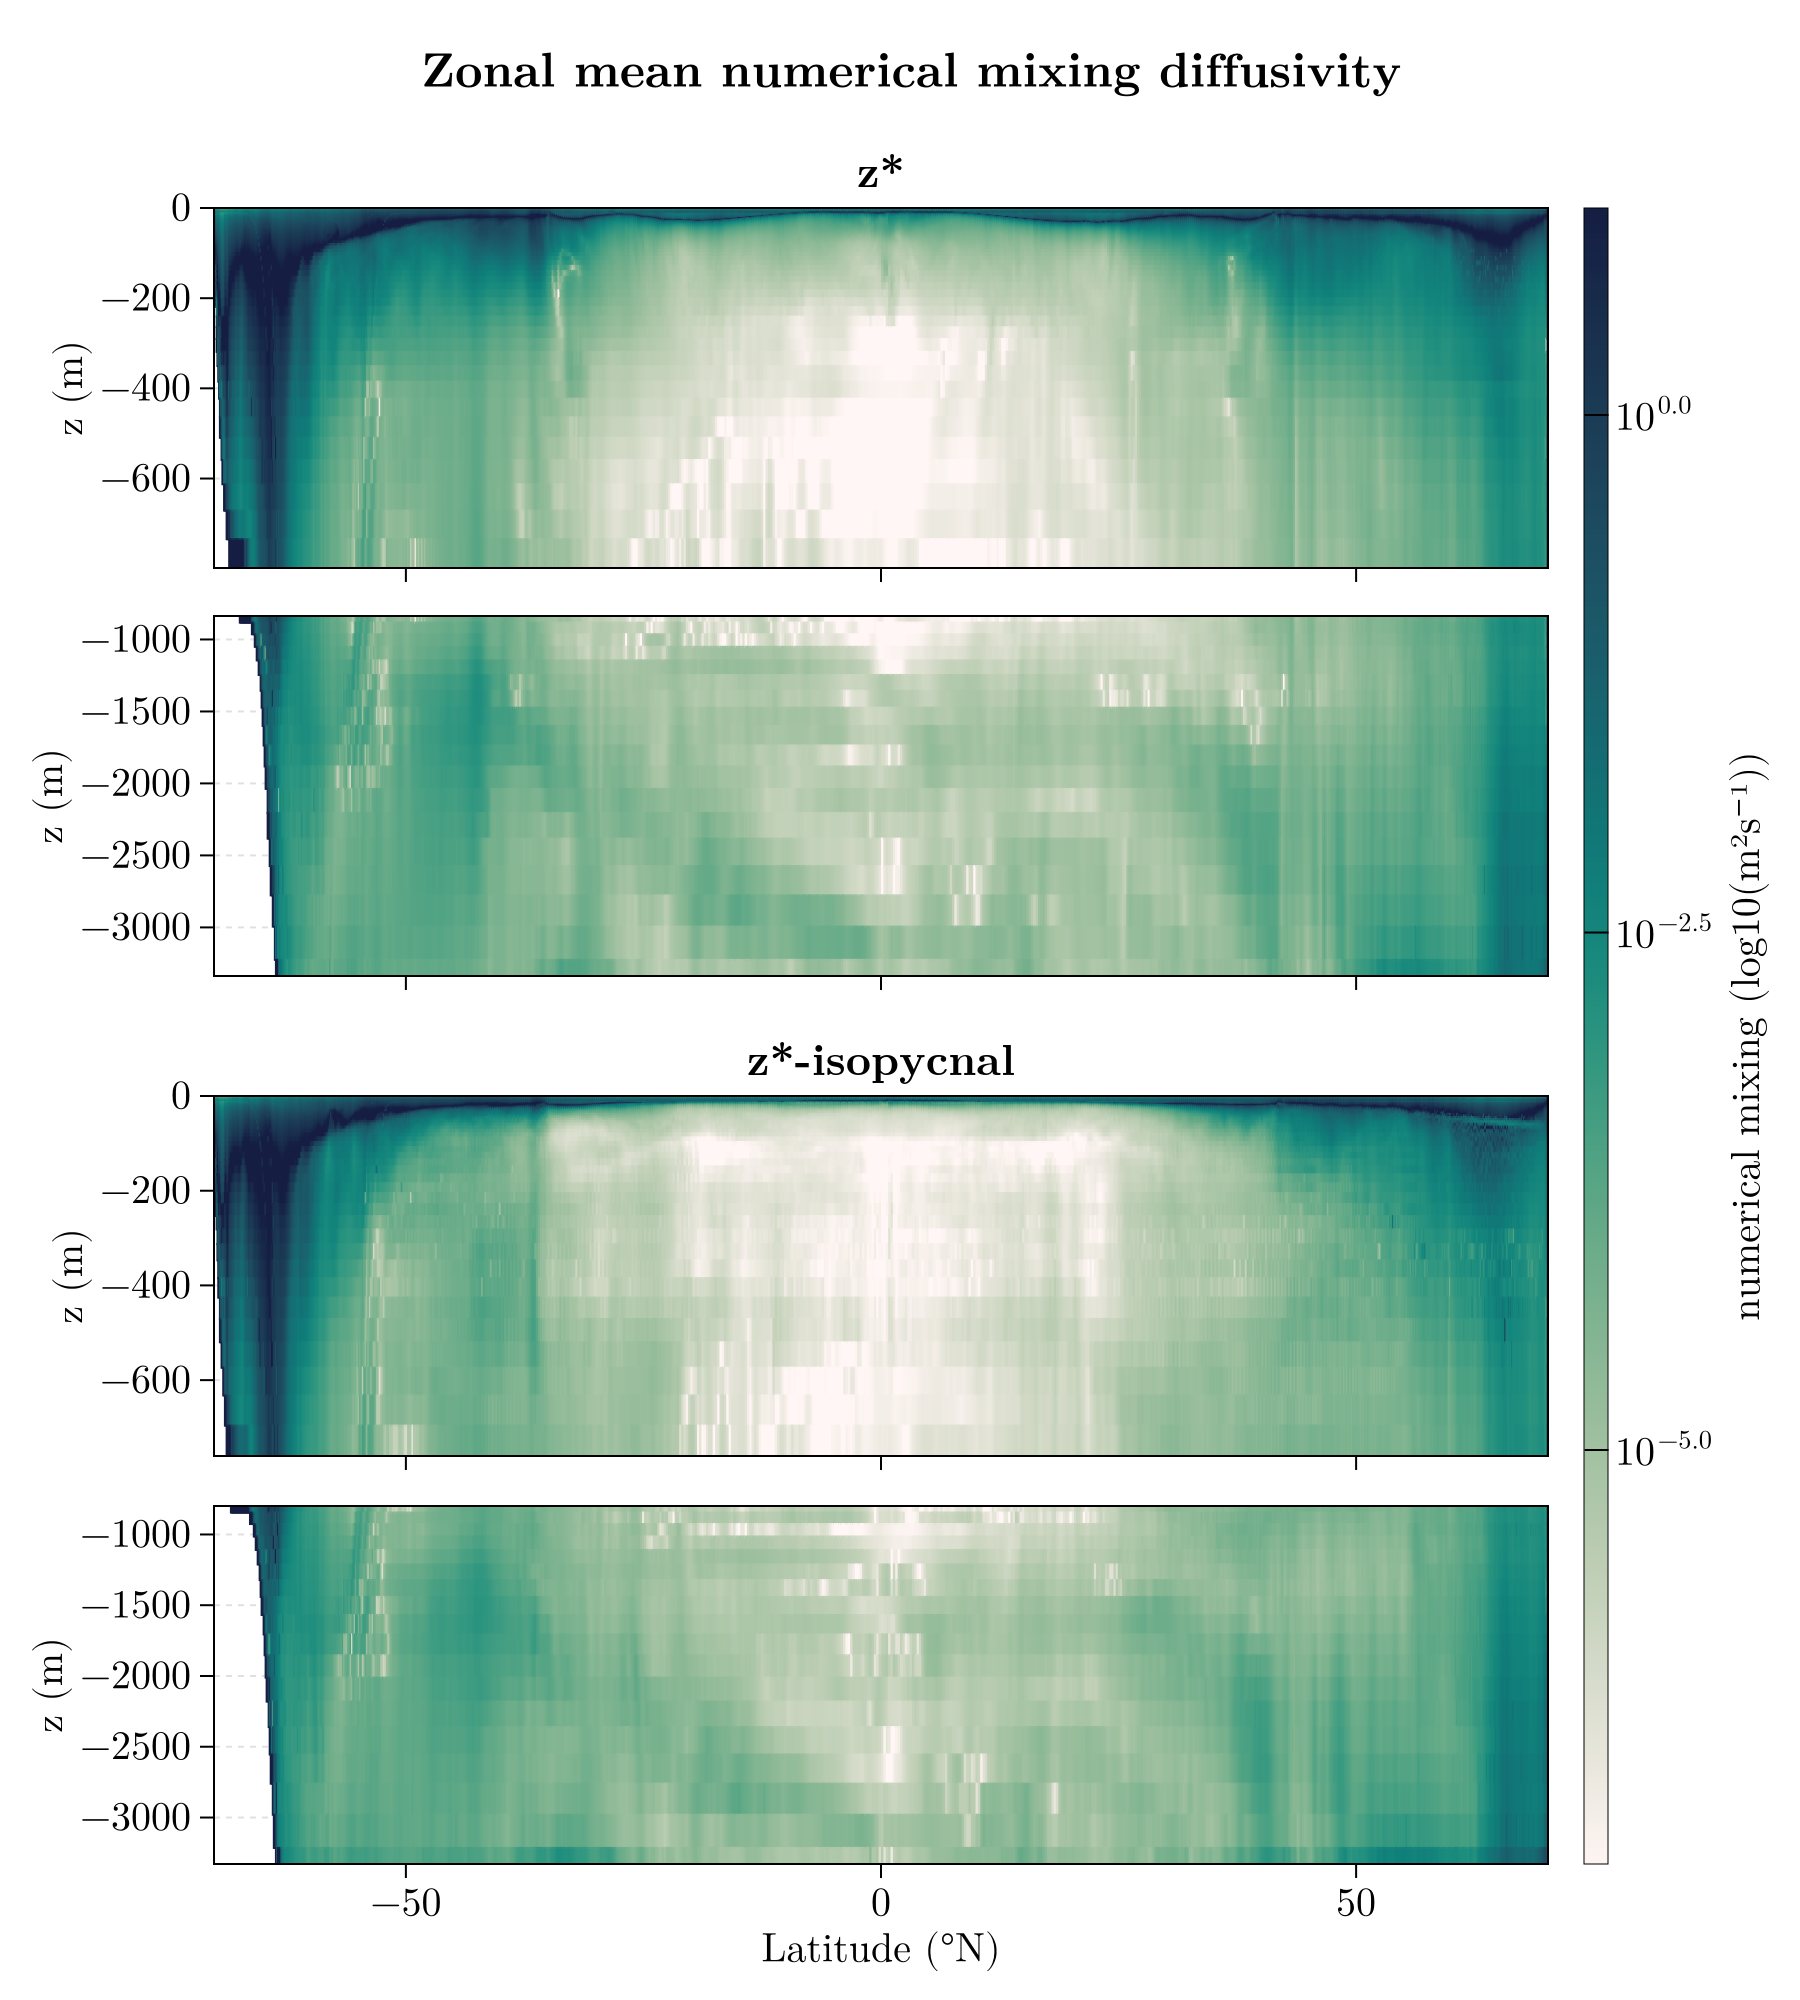

In [41]:
fig = Figure(size = (900, 1000))

colormap = :tempo

top = 1:55
bot = top[end]+1:73
    
colorrange = (1e-7, 1e1)
colorscale = log10

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = title = "z*")
hm = heatmap!(axtop, crs_zstar.lath, crs_zstar.zl[top], nm_zstar_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_zstar.lath, crs_zstar.zl[bot], nm_zstar_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_zstar.zl[bot[end]], crs_zstar.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[3, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "z*-isopycnal")
hm = heatmap!(axtop, crs_hycom.lath, crs_hycom.zl[top], nm_hycom_diff[:, top]; colorrange, colorscale, colormap)
axbot = Axis(fig[4, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, crs_hycom.lath, crs_hycom.zl[bot], nm_hycom_diff[:, bot]; colorrange, colorscale, colormap)
ylims!(axbot, crs_hycom.zl[bot[end]], crs_hycom.zl[bot[1]])

hidexdecorations!(axtop, ticks = false)

Colorbar(fig[:, 2], hm, label = "numerical mixing (log10(m²s⁻¹))")

Label(fig[0, :], "Zonal mean numerical mixing diffusivity", fontsize = 24, font = :bold)

fig

In [ ]:
save("numerical_diffusivity.png", fig)

## Global numerical mixing

In [4]:
ds = NCDataset(catalogue["zstar-PPMH3"]["monthly"], maskingvalue = NaN)
θ = ds["thetao"][:, :, :, :]              # °C
h = ds["thkcello"][:, :, :, :]            # m
nm = ds["T_numerical_mixing"][:, :, :, :] # °C²ms⁻¹
t = ds["time"][:]
close(ds)

ds = NCDataset(catalogue["zstar-PPMH3"]["static"], maskingvalue = NaN)
ΔA = ds["areacello"][:, :]
close(ds)

closed Dataset

In [5]:
# Volume weighted variance dissipation
t_seconds = Dates.Second.(t[2:end] - t[1:end-1])
Δt⁻¹ = 1 ./ Dates.value.(t_seconds)      # s
θ .*= θ # θ is now θ²
θ .*= h # θ is now hθ²
for i ∈ axes(θ, 4)
    for k ∈ axes(θ, 3)
        θ[:, :, k, i] .*= ΔA # θ is now hΔAθ² = ΔVθ² which matches equation (32) in MS
    end
end
∫θ²ΔV = nansum(θ, dim = (1, 2, 3)) # sum over x, y and z dimesions (also drop these dimensions)
Δt⁻¹∫θ²ΔV  = Δt⁻¹ .* (∫θ²ΔV[2:end] .- ∫θ²ΔV[1:end-1]) 

11-element Vector{Float64}:
 -9.500019422690271e10
 -7.674355256413748e10
 -6.532534806101887e10
 -5.694601291534037e10
 -5.048036831015878e10
 -4.5260721407562744e10
 -4.091939185978782e10
 -3.728719952522764e10
 -3.420993648650171e10
 -3.1516731484507687e10
 -2.9143337340280655e10

In [6]:
# Area integrated numerical thickness weighted variance dissipation
for i ∈ axes(nm, 4)
    for k ∈ axes(nm, 3)
        nm[:, :, k, i] .*= ΔA # hΔAΔθ² which matches equation (32) in MS
    end
end
∫nmΔA = nansum(nm, dim = (1, 2, 3)) # <=> Area integrate equation (30)

12-element Vector{Float64}:
 -1.261325091749721e9
 -1.348813475239756e9
 -1.3351880883739753e9
 -1.2465904558350892e9
 -1.1606384250487986e9
 -1.081372223933226e9
 -1.0219296437229818e9
 -9.487295718093168e8
 -9.376113319140964e8
 -8.856598568848091e8
 -8.473339761232153e8
 -7.839674282244416e8

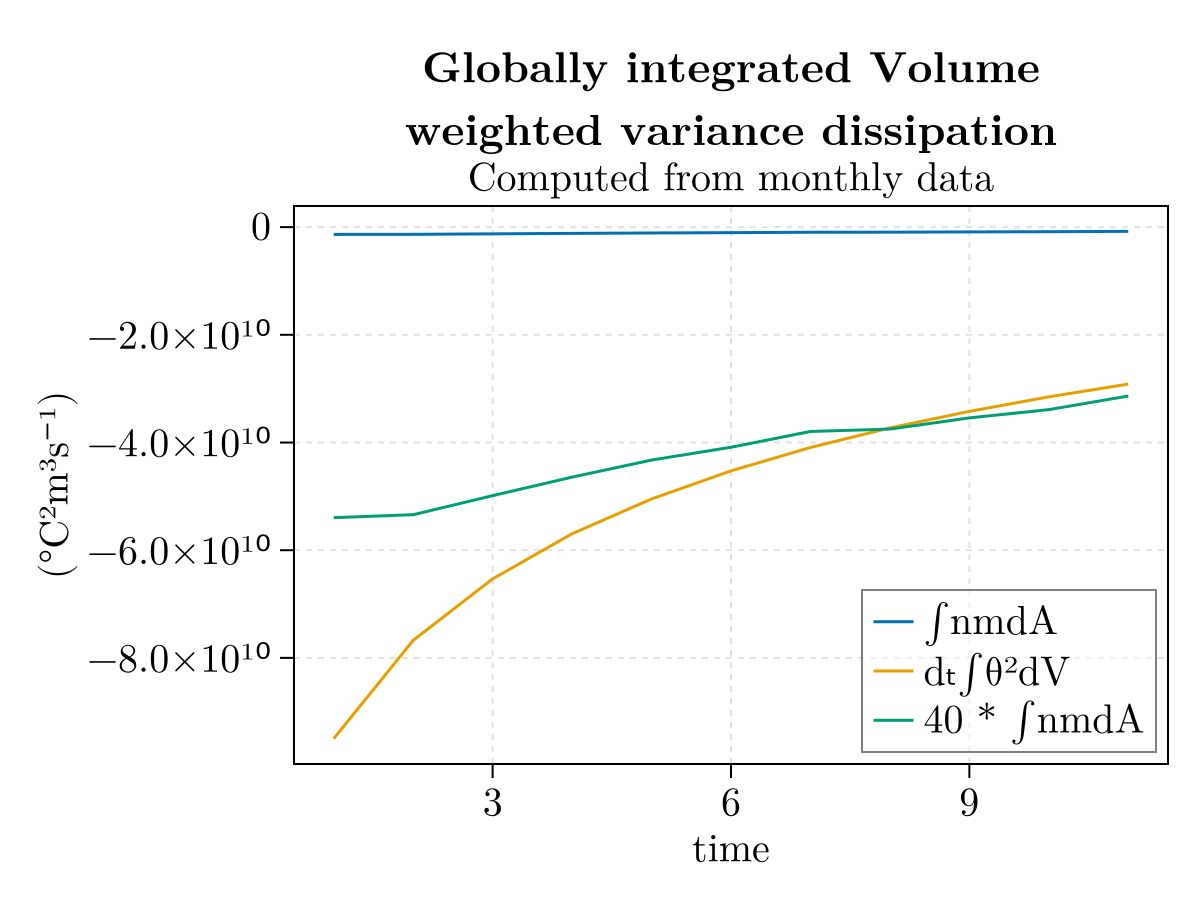

In [17]:
fig, ax = lines(∫nmΔA[2:end], label = "∫nmdA")
lines!(ax, Δt⁻¹∫θ²ΔV, label = "dₜ∫θ²dV")
lines!(ax, 40 * ∫nmΔA[2:end], label = "40 * ∫nmdA")
axislegend(ax, position = :rb)
ax.xlabel = "time"
ax.ylabel = "(°C²m³s⁻¹)"
ax.title = "Globally integrated Volume\nweighted variance dissipation"
ax.subtitle = "Computed from monthly data"
fig

In [85]:
save("global_dissipation.png", fig)